## **Towards fibers in qim3d**

**I D E A S /--/ T O - D O S**

- The need for a fiber Class?
  - Fibers is just a list of ordered points, not really need for a class
  - However, fibers in qim3d is just not ordered point sets > is it ordered pointsets RELATED to a 3D volume
  - The class should then contain pointsets and references to various volumetric files (microCT file, segmentation/label volume)
- Functions / functionality required
  - [x] Fiber smoothing
  - [x] Fiber resampling
  - [ ] Fiber statistics (length, curvature, orientation, local orientation, tortuosity ... )
  - [x] Fiber direction vectors
  - [ ] Fiber-2-labelmask (unique label vs. common label)
  - [ ] Fiber clustering (QuickBundles)
  - [ ] Fiber directionality statistics
- Visualization functionality
  - [x] Centerlines as thin closed cylinder meshes (controllable radius)
  - [ ] Display image slice with fiber centerlines marked
  - [ ] Fiber teasing
  - [x] Spagetti-plot
  - [x] Start-2-end plot (transparency on the actual path)
  - [ ] Coloring: Unique or common
  - [ ] Direction coloring
  - [ ] Length coloring
- Interface to other methods
  - [ ] Layered segmentation from fiber centerlines
- Things to handle
  - [ ] Variable input types. Input "fibers" should be able to be a list, a single array of [x,y,z], or fiber class

**Interesting problems:**

Interpolation of fiber centerlines
- Pick a random slice through volume
- Interpolate all centerline points from fibers in that slice
Can this be solved by image sampling - convert fibers to volumetric domain and resample the volume at slice positions?
Alternatively, the slice is a mathematical plane and the problem is a plane-vector intersection problem -- there is just a shitload of vectors!
How about this idea:
- Make the direct vector between each start and end point -- i.e. N vectors
- Find the vector plane intersection, and calculate the distance along the vector -- i.e. the distance from start point to intersection.
- This distance will sort of tell you how far you need to move along the centerline in order to find the correct local centerline vector which might intersect the plane
- If uni-directional fibers, you have the z-value of intersection and then search for each centerline which two z-values comes closest (consectutive pairs of z-values?)    

In [1]:
import qim3d
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import os
from typing import List, Optional, Tuple

import fiber_functions
from fiberBundleClass import FiberBundle

In [2]:
# Class functionality
def fiber_print(fibers):
    nFib = len(fibers)
    dim = fibers[0].shape[1]
    
    line_size = np.zeros(shape=(nFib,1))
    for j in range(0, nFib):
        line_size[j] = fibers[j].shape[0]

    print('Fibers:')
    print(f'-- Fiber count: {nFib} ')
    print(f'-- Dimensionality: {dim} ')
    print(f'-- Avg. fiber length: {np.mean(line_size):.2f} ')
    print(f'-- Shortest fiber length: {np.min(line_size)} ')
    print(f'-- Longest fiber length: {np.max(line_size)} ')

## **Tutorial / Testing**

**Generation of fibers**, starting with random lines

In [3]:
# Random fibers centerlines
nFib = 16
volume_size = 64
fibers = fiber_functions.generate_random_lines(N=nFib, steps=volume_size, step_size=1.0)
fiber_print(fibers)

Fibers:
-- Fiber count: 16 
-- Dimensionality: 3 
-- Avg. fiber length: 64.00 
-- Shortest fiber length: 64.0 
-- Longest fiber length: 64.0 


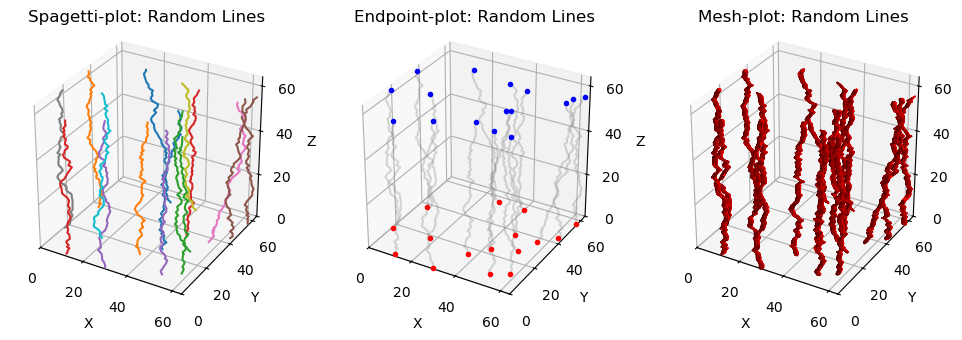

In [4]:
# Plotting
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(131, projection='3d')
fiber_functions.spagetti_plot(ax, fibers, title_string='Spagetti-plot: Random Lines')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])
ax.set_aspect('equal')

ax = fig.add_subplot(132, projection='3d') 
fiber_functions.endpoints_plot(ax, fibers, start_color='r', end_color='b', title_string='Endpoint-plot: Random Lines')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])
ax.set_aspect('equal')

ax = fig.add_subplot(133, projection='3d') 
fiber_functions.mesh_plot(ax, fibers, title_string='Mesh-plot: Random Lines', radius=0.8, radial_resolution=6, backend='matplotlib')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])
ax.set_aspect('equal')

**Generation of fibers**, reading slicewise centers from a segmented volume

In [5]:
# The original volume and a corresponding segmentation
vol_CT = qim3d.examples.NT_128x128x128
vol_CT = np.transpose(vol_CT, [2, 1, 0])
#vol_bin = qim3d.io.load('../qim3d/qim3d/examples/NT_128x128x128_axon_segment.tif') # Update when segmentation can be called with .examples
vol_bin = qim3d.examples.NT_128x128x128_axon_segment

In [6]:
# Slicewise generation of fibers
nerve_fibers = fiber_functions.generate_slicewise_lines(vol_bin, axis=2)
fiber_print(nerve_fibers)

Fibers:
-- Fiber count: 8 
-- Dimensionality: 3 
-- Avg. fiber length: 103.25 
-- Shortest fiber length: 67.0 
-- Longest fiber length: 126.0 


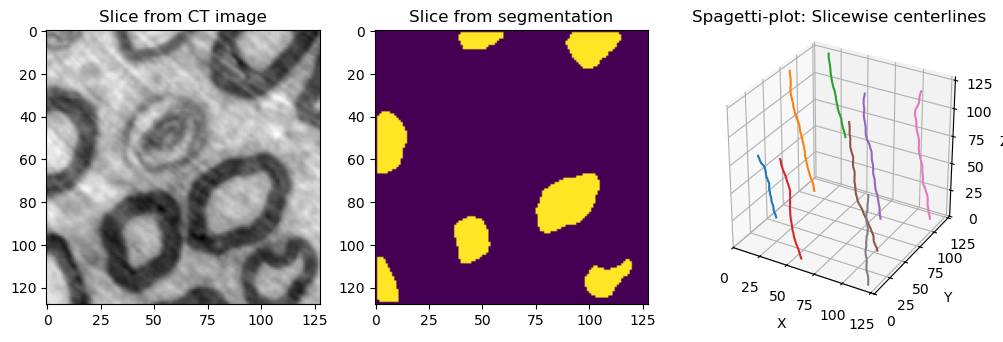

In [7]:
# Plotting
slice_number = 30

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(131)
ax.imshow(vol_CT[:,:,slice_number], cmap='gray')
ax.set_title('Slice from CT image')

ax = fig.add_subplot(132)
#ax.imshow(np.matrix.transpose(vol_bin[:,:,slice_number]))
ax.imshow(vol_bin[:,:,slice_number])
ax.set_title('Slice from segmentation')

ax = fig.add_subplot(133, projection='3d')
fiber_functions.spagetti_plot(ax, nerve_fibers, title_string='Spagetti-plot: Slicewise centerlines')
ax.set_xlim([0, 128])
ax.set_ylim([0, 128])
ax.set_zlim([0, 128])
ax.set_aspect('equal')


In [8]:
#import nibabel as nib
#niiVol = nib.load('NT_128x128x128_axon_segment.nii.gz')
#nerve_fibers = fiber_functions.generate_slicewise_lines(niiVol.get_fdata(), axis=2)
#fiber_print(nerve_fibers)

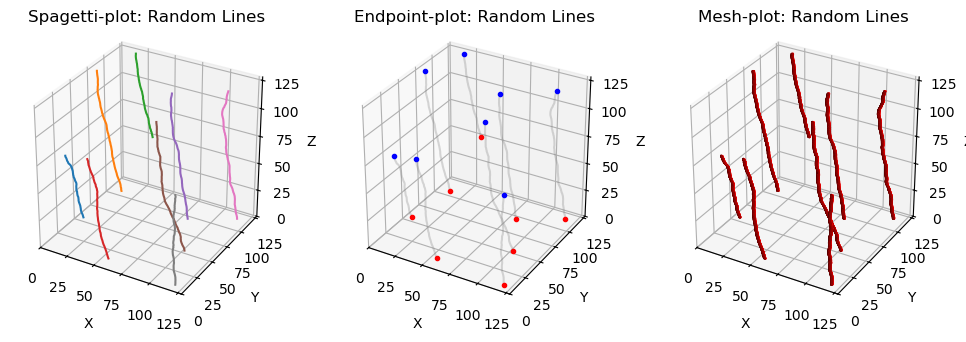

In [9]:
# Plotting
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(131, projection='3d')
fiber_functions.spagetti_plot(ax, nerve_fibers, title_string='Spagetti-plot: Random Lines')
ax.set_xlim([0, 128])
ax.set_ylim([0, 128])
ax.set_zlim([0, 128])
ax.set_aspect('equal')

ax = fig.add_subplot(132, projection='3d') 
fiber_functions.endpoints_plot(ax, nerve_fibers, start_color='r', end_color='b', title_string='Endpoint-plot: Random Lines')
ax.set_xlim([0, 128])
ax.set_ylim([0, 128])
ax.set_zlim([0, 128])
ax.set_aspect('equal')

ax = fig.add_subplot(133, projection='3d') 
fiber_functions.mesh_plot(ax, nerve_fibers, title_string='Mesh-plot: Random Lines', radius=0.8, radial_resolution=6, backend='matplotlib')
ax.set_xlim([0, 128])
ax.set_ylim([0, 128])
ax.set_zlim([0, 128])
ax.set_aspect('equal')

## **Testing FiberClass**

In [10]:
NT_Bundle = FiberBundle(
    centrelines = nerve_fibers,
    voxel_size = [0.5, 0.5, 0.5],
    volume_dimensions = [128, 128, 128],
    origin = [0.0, 0.0, 0.0],
    volume_path = 'C:\\Users\\hmkj\\Desktop\\QIM\\qim_repos\\qim3d\\qim3d\\examples\\NT_128x128x128.tif',
)

In [21]:
ufold = fiber_functions.unfold_fiber(NT_Bundle, fiber_id = 5, radius_max=35, n_spokes=64, n_samples=12)

Using virtual stack


In [22]:
qim3d.viz.slicer(ufold, slice_axis=0)

interactive(children=(IntSlider(value=63, description='Slice', max=125), Output()), layout=Layout(align_items=…

## **Operations on fibers**,
Starting with smoothing

(0.0, 64.0)

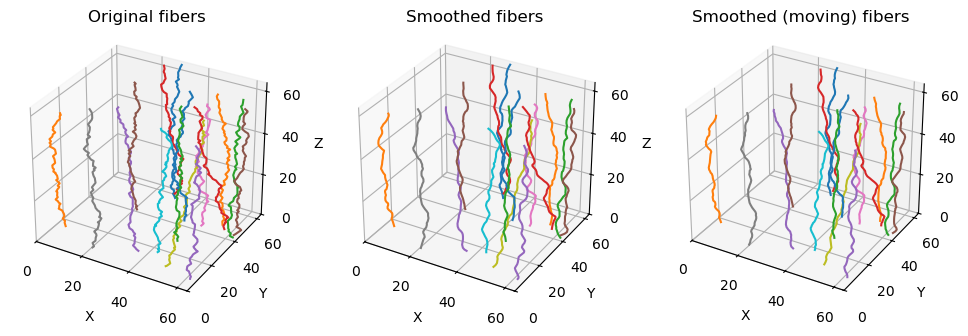

In [52]:
# Demonstrating smoothing
sfibers_1 = fiber_functions.smooth_fibers(fibers, method='savgol', filter_size=6)
sfibers_2 = fiber_functions.smooth_fibers(fibers, method='moving', filter_size=3)

# Plotting
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(131, projection='3d')
fiber_functions.spagetti_plot(ax, fibers, title_string='Original fibers')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])

ax = fig.add_subplot(132, projection='3d')
fiber_functions.spagetti_plot(ax, sfibers_1, title_string='Smoothed fibers')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])

ax = fig.add_subplot(133, projection='3d')
fiber_functions.spagetti_plot(ax, sfibers_2, title_string='Smoothed (moving) fibers ')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])

**Resampling operations**

Fibers:
-- Fiber count: 16 
-- Dimensionality: 3 
-- Avg. fiber length: 14.44 
-- Shortest fiber length: 14.0 
-- Longest fiber length: 15.0 


(0.0, 64.0)

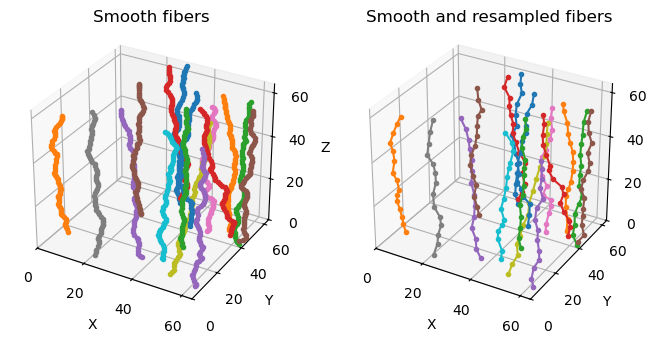

In [53]:
# Demonstrating resampling
rfibers = fiber_functions.resample_fibers(sfibers_1, sectioning_distance=5)
fiber_print(rfibers)

# Plotting
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(121, projection='3d')
fiber_functions.spagetti_plot(ax, sfibers_1, format_string='.-', title_string='Smooth fibers')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])

ax = fig.add_subplot(122, projection='3d')
fiber_functions.spagetti_plot(ax, rfibers, format_string='.-', title_string= 'Smooth and resampled fibers')
ax.set_xlim([0, volume_size])
ax.set_ylim([0, volume_size])
ax.set_zlim([0, volume_size])


**Quantification operations,**

In [54]:
## Demonstrating statistics
length_of_fibers = fiber_functions.measure_fiber_statistics(rfibers, stat='length', voxel_size=1.0)
straigtness_of_fibers = fiber_functions.measure_fiber_statistics(rfibers, stat='tortuosity', voxel_size=1.0)

print(length_of_fibers)
print(straigtness_of_fibers)

[[62.08501863]
 [66.24451994]
 [61.51939697]
 [62.68911858]
 [61.2919827 ]
 [61.88852032]
 [66.57567263]
 [62.69842124]
 [67.03751367]
 [66.79394145]
 [67.25937881]
 [62.65718421]
 [61.64753576]
 [65.36923608]
 [61.09617162]
 [65.41606115]]
[[0.95942583]
 [0.95347925]
 [0.96624823]
 [0.94561991]
 [0.97188357]
 [0.95828722]
 [0.93728353]
 [0.95288862]
 [0.96830827]
 [0.93464691]
 [0.93319308]
 [0.95165292]
 [0.95841492]
 [0.9404991 ]
 [0.9650528 ]
 [0.96144842]]
